In [1]:
import math

from common import *
from experiment import *
from data import RawData, PlottableData, DirectRawData

In [2]:
def TREATMENTS(protocol='picoquic', prefix='quic'):
    network_options = ['--freq-ms', '25', '--freq-pkts', '8', '--network-statistics']
    return [
        Treatment(protocol, label=f'picoquic_split', network_options=network_options + ['--proxy', 'picoquic'], protocol_options=[]),
        Treatment(protocol, label=f'picoquic', network_options=network_options, protocol_options=[]),
        Treatment(protocol, label=f'picoquic_sidekick_30ms', network_options=network_options + ['--proxy', 'sidekick'], protocol_options=['--ack-delay', '30', '--client-quacker']),
    ]

def BBR_TREATMENTS(cca):
    treatments = TREATMENTS()
    for treatment in treatments:
        treatment._label += f'_{cca}'
        treatment._protocol_options += ['-cca', cca]
    return treatments

LOSS1_VALUES = [0, 1, 2, 4, 6, 8] #, 10, 12]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=4, delay2=100, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]

def DATA_SIZES(bottleneck_bw=20):
    return [bottleneck_bw * 1250000]

    

# Collect data for experiments

In [3]:
# NOTE: We have to run one trial at a time with the sidekick since it can only handle one connection at a time,
# and it decides which connection to handle by the first UDP packet it observes
for i in range(1, 2):
    exp = Experiment(num_trials=i, treatments=BBR_TREATMENTS('bbr1'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True, retry=4)
    exp = Experiment(num_trials=i, treatments=BBR_TREATMENTS('bbr'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True, retry=4)
    exp = Experiment(num_trials=i, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True, retry=4, max_networks={'picoquic': 7})

In [4]:
n = 1
exp = Experiment(num_trials=n, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
cubic_raw_data = RawData(exp, execute=False, max_networks={'picoquic': 7})
exp = Experiment(num_trials=n, treatments=BBR_TREATMENTS('bbr1'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
bbr1_raw_data = RawData(exp, execute=False)
exp = Experiment(num_trials=n, treatments=BBR_TREATMENTS('bbr'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
bbr3_raw_data = RawData(exp, execute=False)

# Plot network metrics

In [5]:
def plot_loss_vs_metric_line(data, title, ylabel, show=True, delta=25):
    plt.figure(figsize=(6, 4))
    
    labels = data.treatments
    assert len(data.data_sizes) == 1
    data_size = data.data_sizes[0]

    # Plot each label
    for label in labels:
        xs = []
        ys_raw = []

        for network in data.network_settings:
            if data_size not in data.data[label][network]:
                continue
            network_setting = data.exp.get_network_setting(network)
            xs.append(float(network_setting.settings['loss1']))
            ys_raw.append(data.data[label][network][data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)

    plt.title(title)
    plt.xlabel('Loss % near data receiver')
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0)
    plt.ylim(0)
    if show:
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
        plt.show()

## Throughput

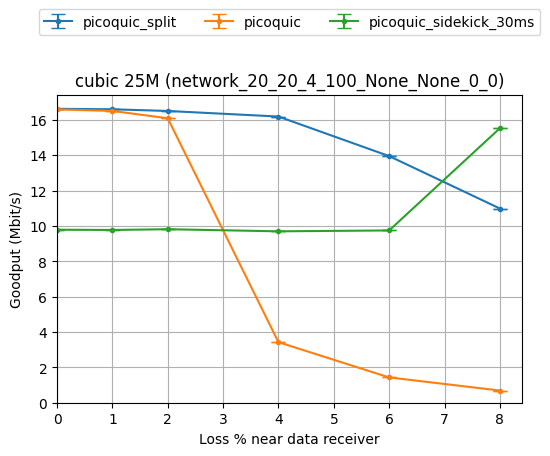

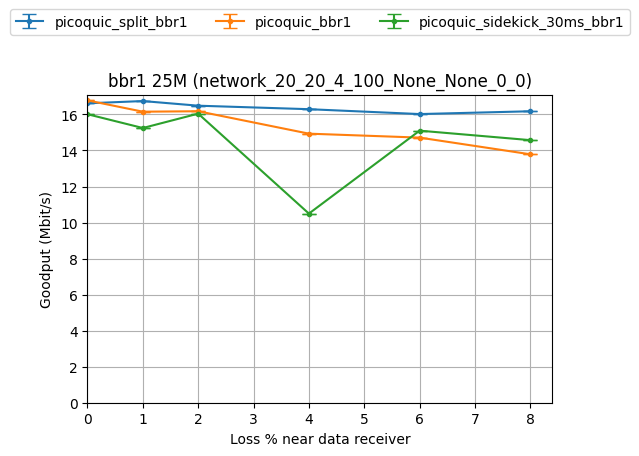

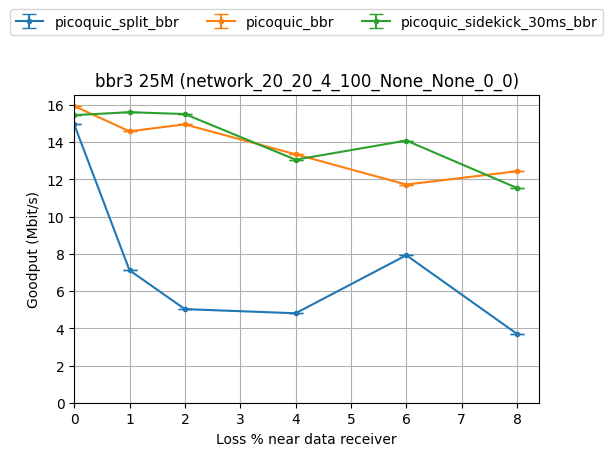

In [6]:
def plot_loss_vs_throughput(prefix, raw_data, title=None, show=True):
    if title == None:
        title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
    ylabel = 'Goodput (Mbit/s)'
    plottable_data = PlottableData(raw_data, 'throughput_mbps')
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel, show=show)

plot_loss_vs_throughput('cubic', cubic_raw_data)
plot_loss_vs_throughput('bbr1', bbr1_raw_data)
plot_loss_vs_throughput('bbr3', bbr3_raw_data)


# End-to-End Picoquic Evaluation

In [34]:
def TREATMENTS(protocol='picoquic', prefix='quic'):
    network_options = []
    return [
        Treatment(protocol, label=f'picoquic', network_options=network_options, protocol_options=[]),
    ]

def BBR_TREATMENTS(cca):
    treatments = TREATMENTS()
    for treatment in treatments:
        treatment._label += f'_{cca}'
        treatment._protocol_options += ['-cca', cca]
    return treatments

LOSS1_VALUES = [0, 1, 2, 4, 8, 16]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=4, delay2=4, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]

def DATA_SIZES(bottleneck_bw=20):
    return [bottleneck_bw * 1250000]

# NOTE: We have to run one trial at a time with the sidekick since it can only handle one connection at a time,
# and it decides which connection to handle by the first UDP packet it observes
for i in range(1, 2):
    #exp = Experiment(num_trials=i, treatments=BBR_TREATMENTS('bbr1'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    #picoquic_raw_data = RawData(exp, execute=True, retry=4)
    #exp = Experiment(num_trials=i, treatments=BBR_TREATMENTS('bbr'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    #picoquic_raw_data = RawData(exp, execute=True, retry=4)
    exp = Experiment(num_trials=i, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True, retry=4, max_networks={'picoquic': 7})

#exp = Experiment(num_trials=n, treatments=BBR_TREATMENTS('bbr1'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
#bbr1_raw_data = RawData(exp, execute=False)
#exp = Experiment(num_trials=n, treatments=BBR_TREATMENTS('bbr'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
#bbr3_raw_data = RawData(exp, execute=False)

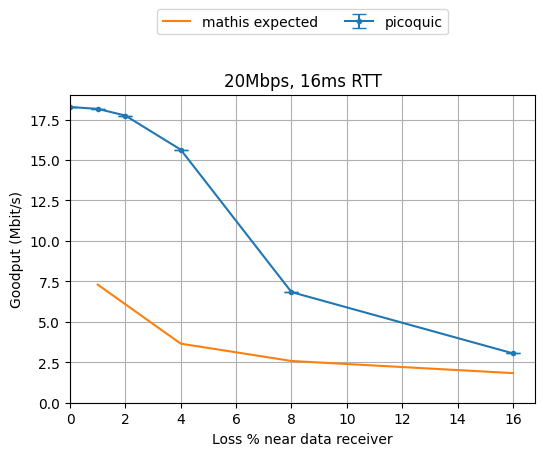

In [52]:
LOSS1_VALUES = [0, 1, 2, 4, 8, 16]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=4, delay2=4, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]
    
exp = Experiment(num_trials=n, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
picoquic_raw_data = RawData(exp, execute=False, max_networks={'picoquic': 7})

mathis_expected_xs = [1, 4, 8, 16]
mathis_expected_ys = [7.3, 3.65, 2.58, 1.83]

plot_loss_vs_throughput('cubic', picoquic_raw_data, title="20Mbps, 16ms RTT", show=False)
plt.plot(mathis_expected_xs, mathis_expected_ys, label='mathis expected')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
plt.show()

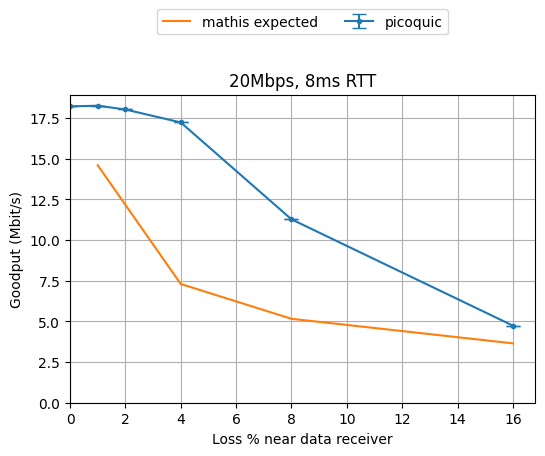

In [49]:
LOSS1_VALUES = [0, 1, 2, 4, 8, 16]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=2, delay2=2, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]

exp = Experiment(num_trials=n, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
picoquic_raw_data = RawData(exp, execute=False, max_networks={'picoquic': 7})

mathis_expected_xs = [1, 4, 8, 16]
mathis_expected_ys = [14.6, 7.3, 5.16, 3.65]

plot_loss_vs_throughput('cubic', picoquic_raw_data, title="20Mbps, 8ms RTT", show=False)
plt.plot(mathis_expected_xs, mathis_expected_ys, label='mathis expected')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
plt.show()